In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130



In [ ]:
print("=" * 60)
print("TASK 2: EXPLORATORY DATA ANALYSIS")
print("Dataset: Restaurant Tips Data")
print("=" * 60)

TASK 2: EXPLORATORY DATA ANALYSIS
Dataset: Restaurant Tips Data


In [ ]:
import ssl, urllib.request

ssl_ctx = ssl.create_default_context()
ssl_ctx.check_hostname = False
ssl_ctx.verify_mode = ssl.CERT_NONE

TIPS_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
try:
    with urllib.request.urlopen(TIPS_URL, context=ssl_ctx) as resp:
        df = pd.read_csv(resp)
    print("\n Dataset loaded from GitHub (SSL bypass)!")
except Exception as e:
    print(f"  Online load failed: {e}")
    # Fallback: download CSV from https://www.kaggle.com/datasets/jsphyg/tipping
    df = pd.read_csv('tips.csv')
    print("\n Dataset loaded from local tips.csv!")

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn Names:", list(df.columns))
print("\n[First 5 Rows]")
print(df.head())


 Dataset loaded from GitHub (SSL bypass)!
Shape: 244 rows × 7 columns

Column Names: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

[First 5 Rows]
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [ ]:
print("\n── STEP 1: Descriptive Statistics ──")
print(df.describe())
print("\nMedian values:")
print(df[['total_bill', 'tip', 'size']].median())
print("\nMode values:")
print(df[['day', 'time', 'sex', 'smoker']].mode().iloc[0])


── STEP 1: Descriptive Statistics ──
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000

Median values:
total_bill    17.795
tip            2.900
size           2.000
dtype: float64

Mode values:
day          Sat
time      Dinner
sex         Male
smoker        No
Name: 0, dtype: object



── STEP 2: Histograms & KDE Plots ──


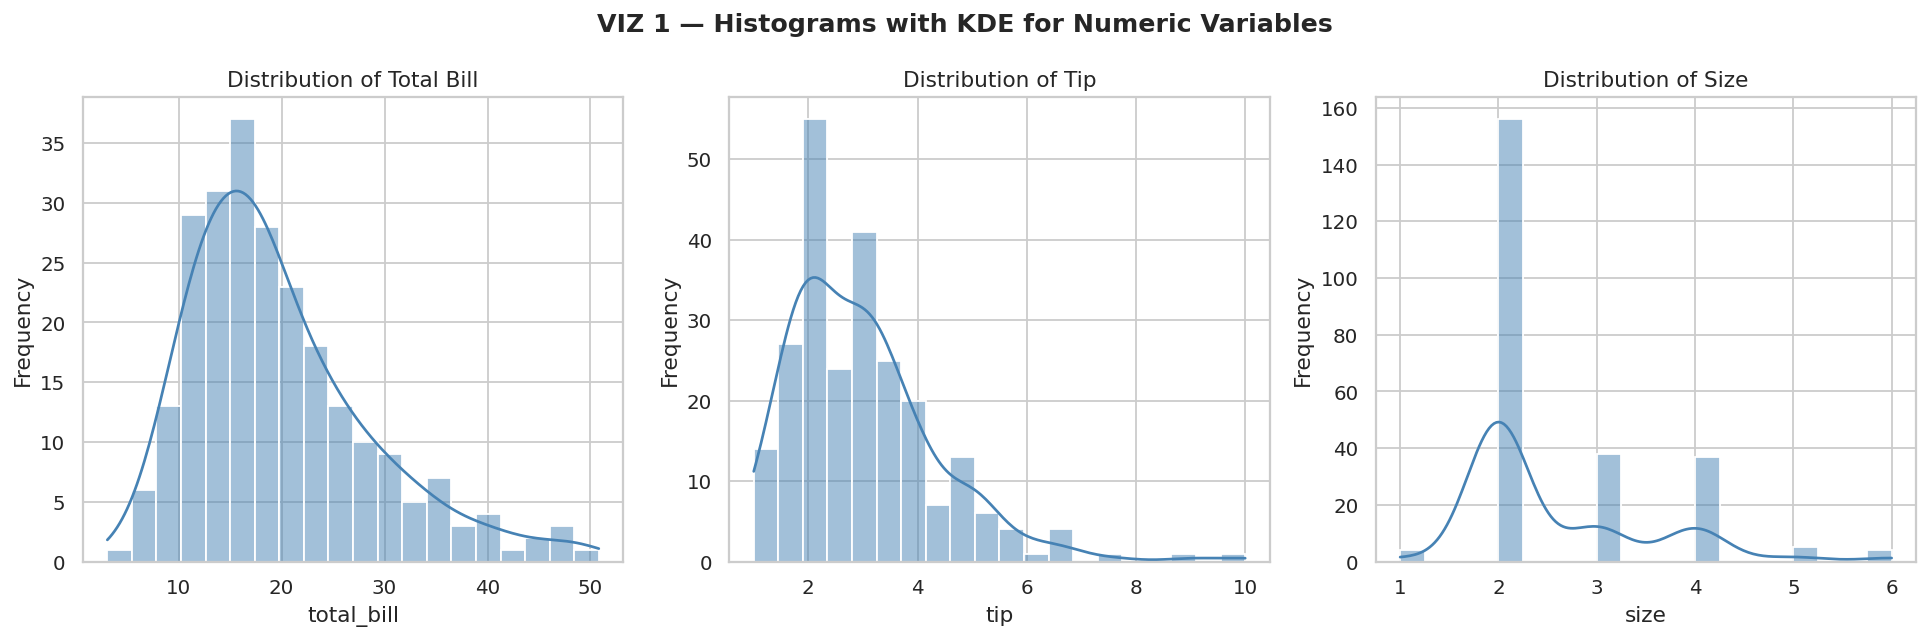

📊 VIZ 1 saved as 'viz1_histograms_kde.png'


In [ ]:
print("\n── STEP 2: Histograms & KDE Plots ──")
num_cols = ['total_bill', 'tip', 'size']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=20)
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('VIZ 1 — Histograms with KDE for Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz1_histograms_kde.png', dpi=150)
plt.show()
print("VIZ 1 saved as 'viz1_histograms_kde.png'")


── STEP 3: Correlation Heatmap ──

Correlation Matrix:
            total_bill    tip   size
total_bill       1.000  0.676  0.598
tip              0.676  1.000  0.489
size             0.598  0.489  1.000


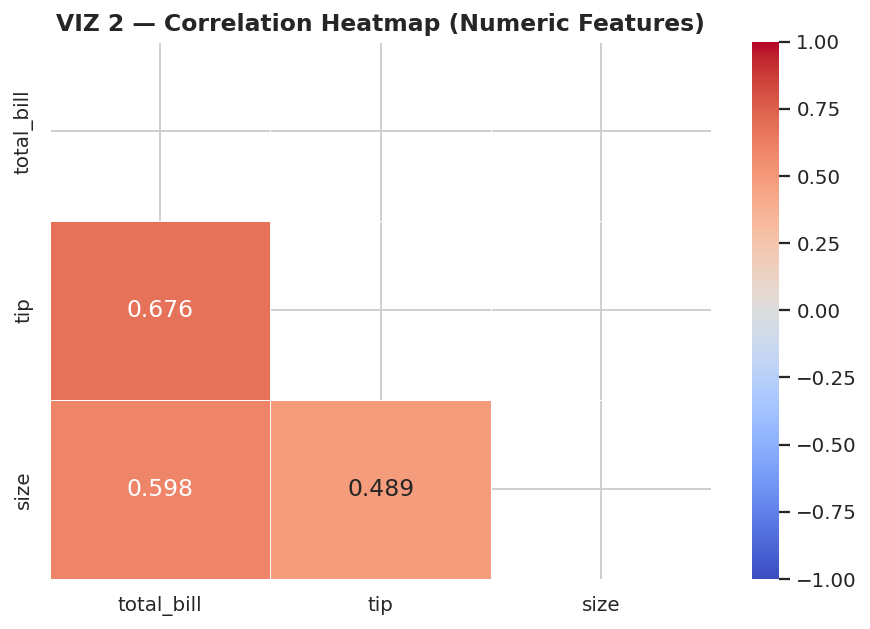

📊 VIZ 2 saved as 'viz2_correlation_heatmap.png'


In [ ]:
print("\n── STEP 3: Correlation Heatmap ──")
corr_matrix = df[['total_bill', 'tip', 'size']].corr()
print("\nCorrelation Matrix:")
print(corr_matrix.round(3))

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 13})
plt.title('VIZ 2 — Correlation Heatmap (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_correlation_heatmap.png', dpi=150)
plt.show()
print("📊 VIZ 2 saved as 'viz2_correlation_heatmap.png'")



── STEP 4: Box Plots by Category ──


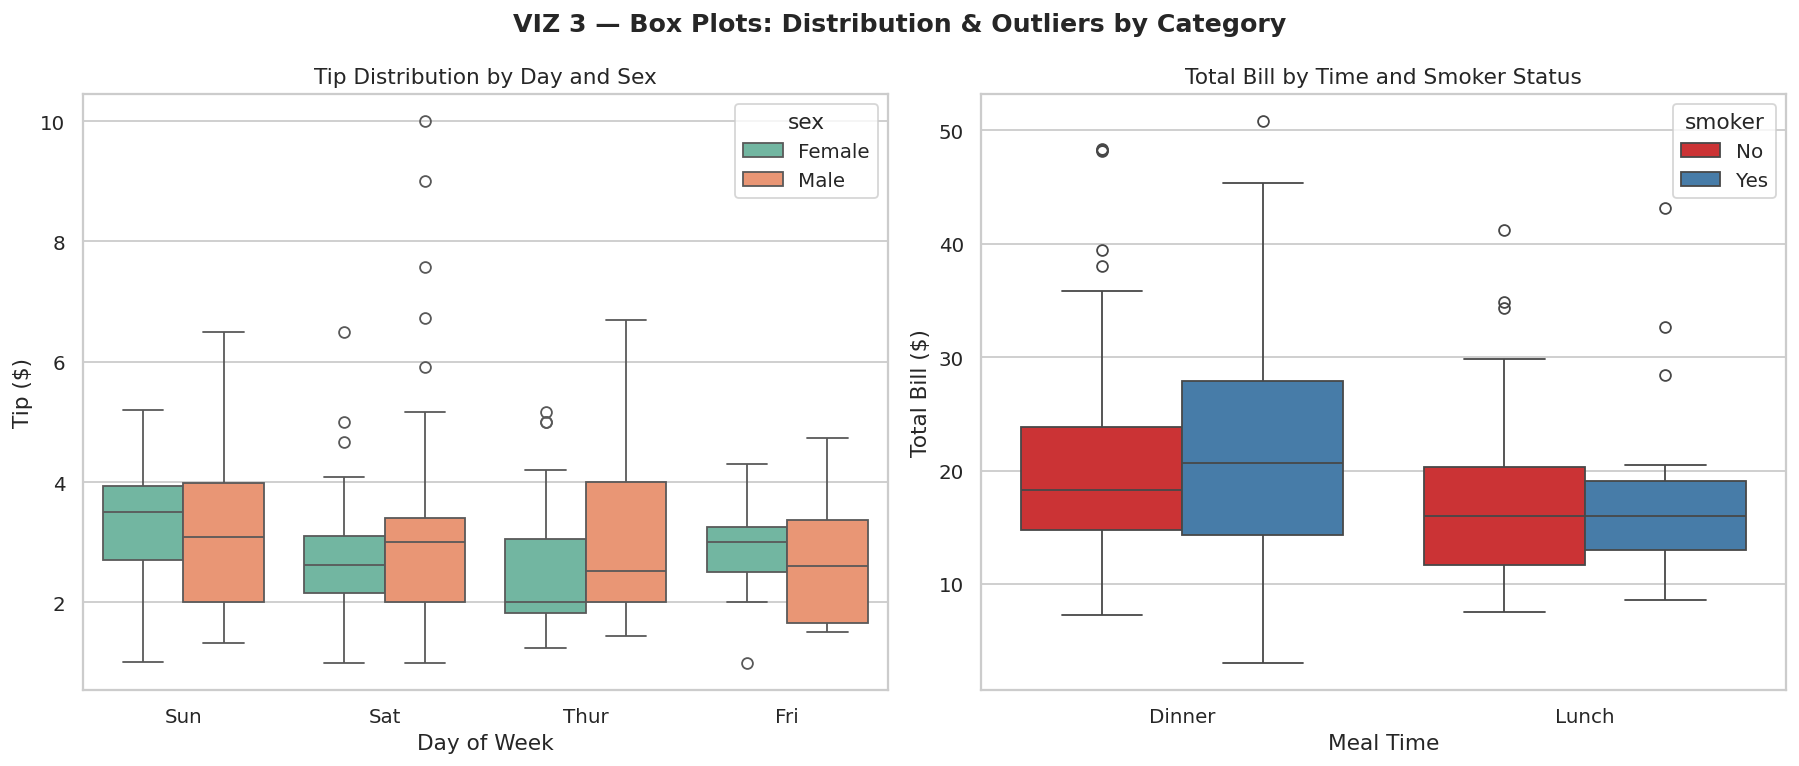

📊 VIZ 3 saved as 'viz3_boxplots_category.png'


In [ ]:
print("\n── STEP 4: Box Plots by Category ──")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='day', y='tip', hue='sex', ax=axes[0], palette='Set2')
axes[0].set_title('Tip Distribution by Day and Sex', fontsize=12)
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Tip ($)')

sns.boxplot(data=df, x='time', y='total_bill', hue='smoker', ax=axes[1], palette='Set1')
axes[1].set_title('Total Bill by Time and Smoker Status', fontsize=12)
axes[1].set_xlabel('Meal Time')
axes[1].set_ylabel('Total Bill ($)')

plt.suptitle('VIZ 3 — Box Plots: Distribution & Outliers by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz3_boxplots_category.png', dpi=150)
plt.show()
print("📊 VIZ 3 saved as 'viz3_boxplots_category.png'")


── STEP 5: Scatter Plot (Relationship Analysis) ──


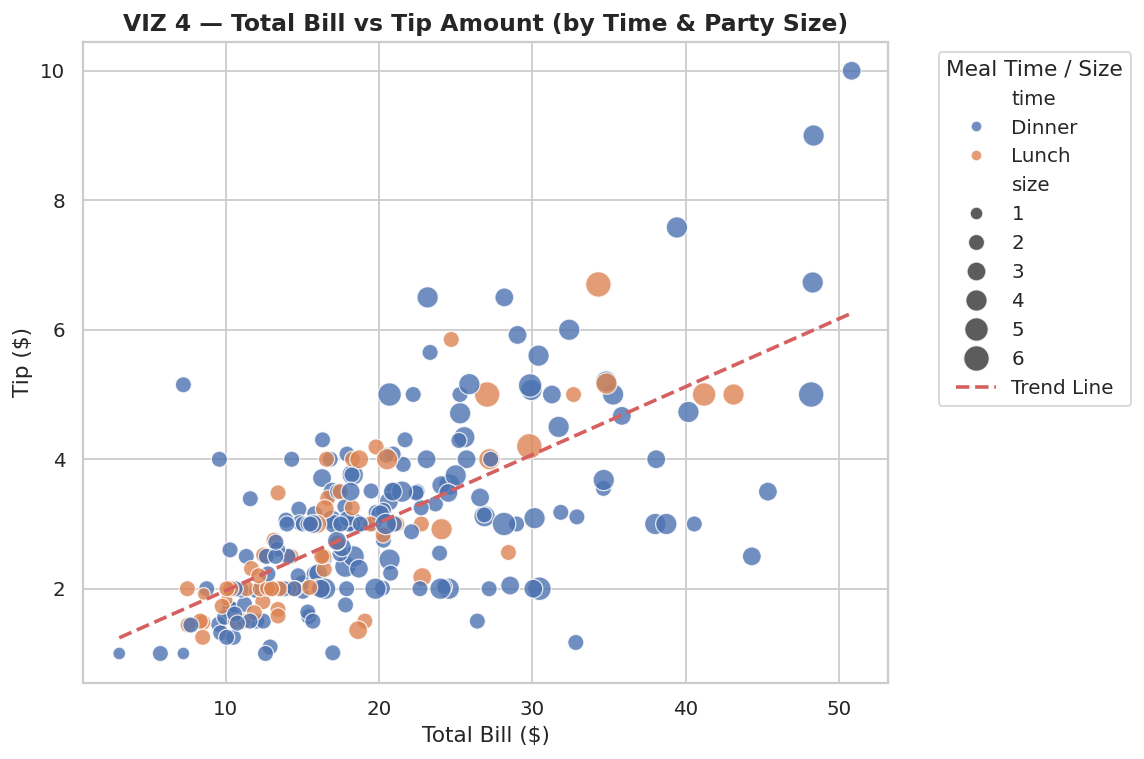

📊 VIZ 4 saved as 'viz4_scatter_bill_vs_tip.png'


In [ ]:
print("\n── STEP 5: Scatter Plot (Relationship Analysis) ──")
plt.figure(figsize=(9, 6))
scatter = sns.scatterplot(data=df, x='total_bill', y='tip',
                          hue='time', size='size', sizes=(50, 200),
                          palette='deep', alpha=0.8)
# Add trend line
z = np.polyfit(df['total_bill'], df['tip'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['total_bill'].min(), df['total_bill'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend Line')
plt.title('VIZ 4 — Total Bill vs Tip Amount (by Time & Party Size)', fontsize=13, fontweight='bold')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.legend(title='Meal Time / Size', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('viz4_scatter_bill_vs_tip.png', dpi=150)
plt.show()
print("📊 VIZ 4 saved as 'viz4_scatter_bill_vs_tip.png'")


── STEP 6: Group-By Analysis ──

Group-By Day Statistics:
    day  avg_tip  avg_bill  total_visits
0   Fri     2.73     17.15            19
1   Sat     2.99     20.44            87
2   Sun     3.26     21.41            76
3  Thur     2.77     17.68            62

Average Tip by Smoker & Sex:
  Smoker     Sex  Avg Tip
0     No  Female    2.774
1     No    Male    3.113
2    Yes  Female    2.932
3    Yes    Male    3.051


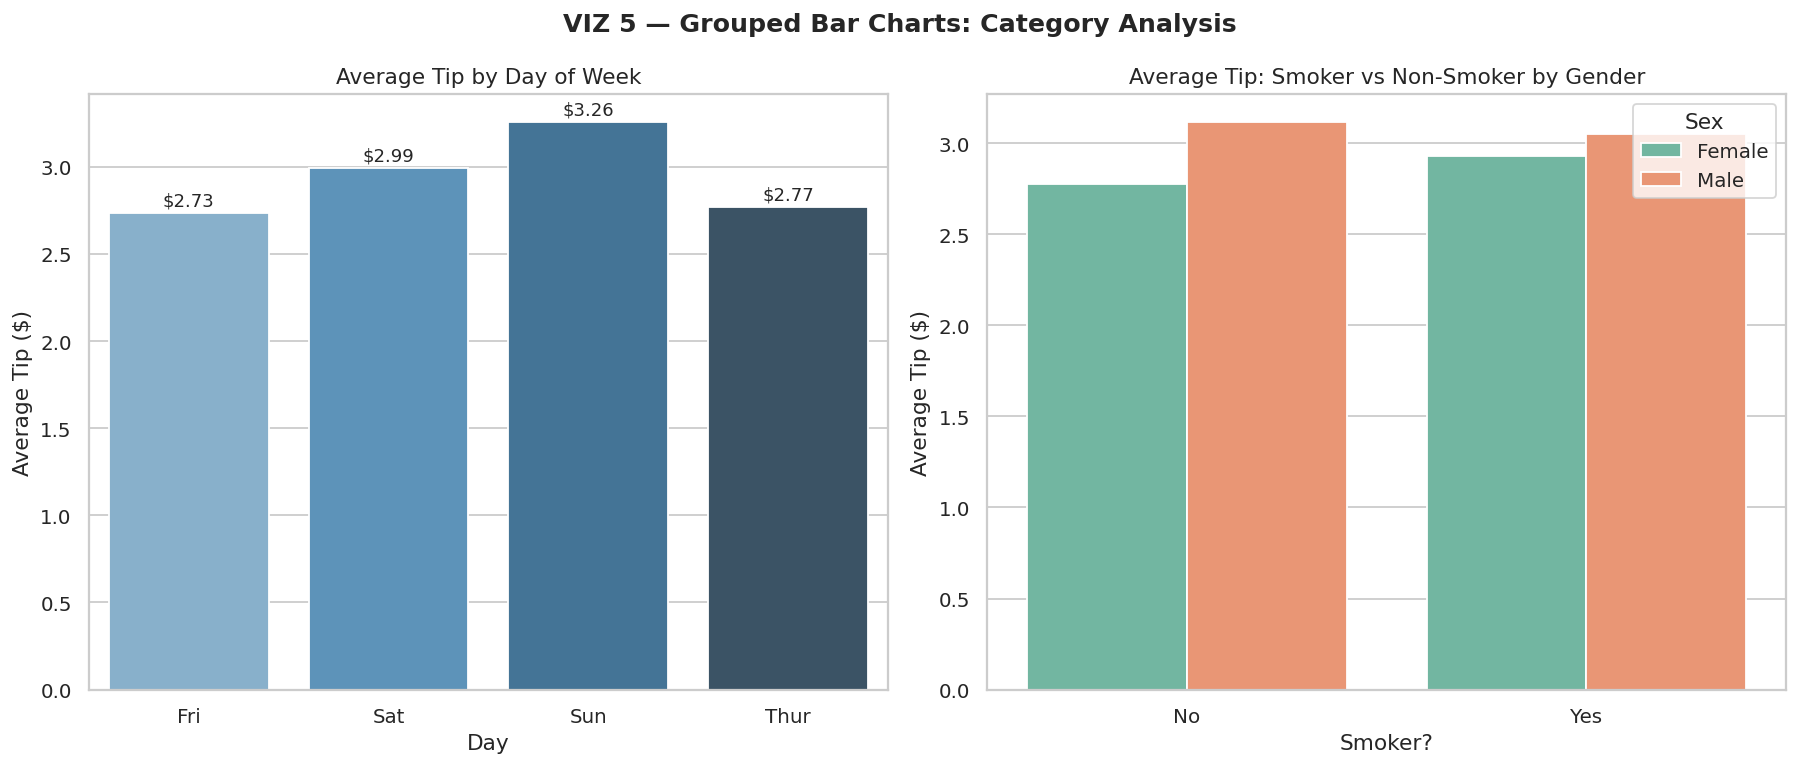

📊 VIZ 5 saved as 'viz5_groupby_barcharts.png'


In [ ]:
print("\n── STEP 6: Group-By Analysis ──")
group_day = df.groupby('day').agg(
    avg_tip=('tip', 'mean'),
    avg_bill=('total_bill', 'mean'),
    total_visits=('tip', 'count')
).reset_index()
print("\nGroup-By Day Statistics:")
print(group_day.round(2))

group_smoker = df.groupby(['smoker', 'sex'])['tip'].mean().reset_index()
group_smoker.columns = ['Smoker', 'Sex', 'Avg Tip']
print("\nAverage Tip by Smoker & Sex:")
print(group_smoker.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=group_day, x='day', y='avg_tip', palette='Blues_d', ax=axes[0])
axes[0].set_title('Average Tip by Day of Week', fontsize=12)
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Average Tip ($)')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'${bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

sns.barplot(data=group_smoker, x='Smoker', y='Avg Tip', hue='Sex',
            palette='Set2', ax=axes[1])
axes[1].set_title('Average Tip: Smoker vs Non-Smoker by Gender', fontsize=12)
axes[1].set_xlabel('Smoker?')
axes[1].set_ylabel('Average Tip ($)')

plt.suptitle('VIZ 5 — Grouped Bar Charts: Category Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz5_groupby_barcharts.png', dpi=150)
plt.show()
print("📊 VIZ 5 saved as 'viz5_groupby_barcharts.png'")


── STEP 7: Derived Feature — Tip Percentage ──


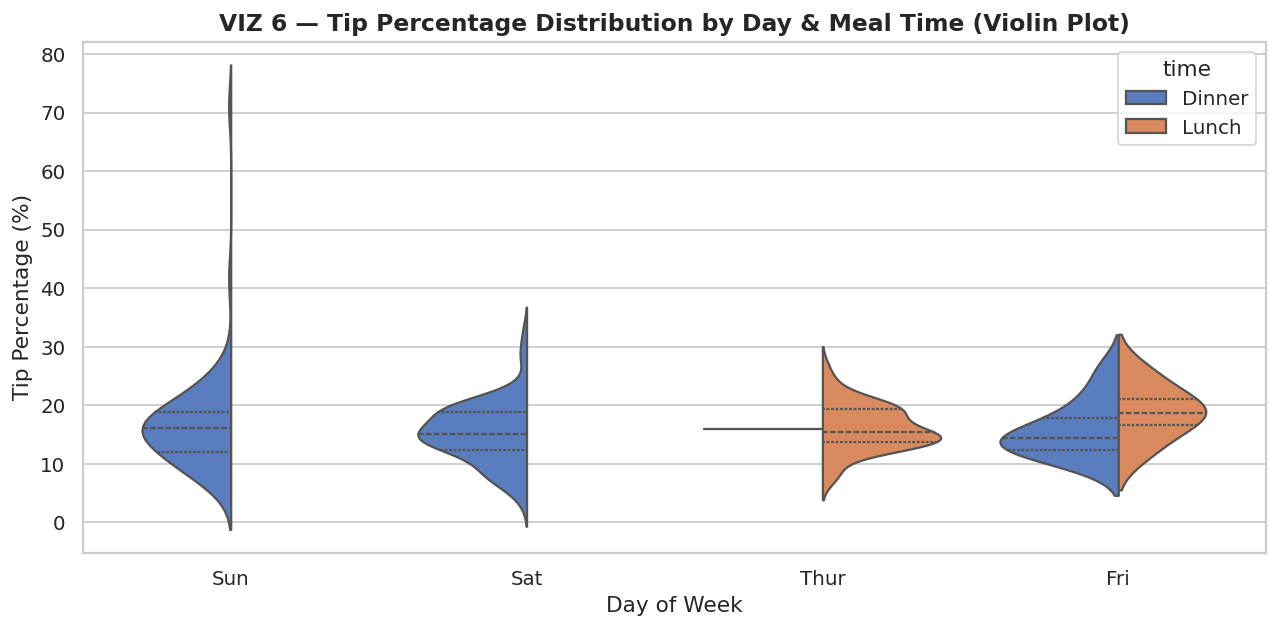

📊 VIZ 6 saved as 'viz6_tip_pct_violin.png'


In [ ]:
print("\n── STEP 7: Derived Feature — Tip Percentage ──")
df['tip_pct'] = (df['tip'] / df['total_bill']) * 100

plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='day', y='tip_pct', hue='time',
               split=True, palette='muted', inner='quartile')
plt.title('VIZ 6 — Tip Percentage Distribution by Day & Meal Time (Violin Plot)',
          fontsize=13, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Tip Percentage (%)')
plt.tight_layout()
plt.savefig('viz6_tip_pct_violin.png', dpi=150)
plt.show()
print("📊 VIZ 6 saved as 'viz6_tip_pct_violin.png'")

In [ ]:
print("\n── STATISTICAL HIGHLIGHTS ──")
corr_bill_tip = df['total_bill'].corr(df['tip'])
avg_tip_pct = df['tip_pct'].mean()
best_day = group_day.loc[group_day['avg_tip'].idxmax(), 'day']
worst_day = group_day.loc[group_day['avg_tip'].idxmin(), 'day']
print(f"  Correlation (total_bill vs tip): {corr_bill_tip:.4f}")
print(f"  Average tip percentage: {avg_tip_pct:.2f}%")
print(f"  Best tipping day: {best_day}")
print(f"  Lowest tipping day: {worst_day}")


── STATISTICAL HIGHLIGHTS ──
  Correlation (total_bill vs tip): 0.6757
  Average tip percentage: 16.08%
  Best tipping day: Sun
  Lowest tipping day: Fri


In [ ]:
print("\n" + "=" * 60)
print(" 3 KEY INSIGHTS & BUSINESS RECOMMENDATIONS")
print("=" * 60)
print("""
INSIGHT 1 — Strong Positive Correlation (Bill → Tip)
  The correlation between total_bill and tip is {:.2f}, meaning higher
  bills almost always yield higher tips. Restaurants should focus on
  upselling (appetizers, drinks, desserts) to naturally boost tip income.

INSIGHT 2 — Sunday Generates the Highest Average Tips
  Sunday averages the highest tip per table (~${:.2f}). This suggests
  weekend diners are more generous. Scheduling experienced servers on
  Sunday and Saturday dinner shifts will maximize earnings.

INSIGHT 3 — Non-Smokers Tip Slightly More on Average
  Non-smoking sections yield marginally higher tips than smoking sections.
  With indoor smoking restrictions now widespread, this aligns with
  broader trends favoring non-smoking environments for upscale dining.

RECOMMENDATION:
  Focus on dinner service (higher bills), train staff on upselling, and
  prioritize table management on weekends for maximum revenue.
""".format(corr_bill_tip, group_day['avg_tip'].max()))


 3 KEY INSIGHTS & BUSINESS RECOMMENDATIONS

INSIGHT 1 — Strong Positive Correlation (Bill → Tip)
  The correlation between total_bill and tip is 0.68, meaning higher
  bills almost always yield higher tips. Restaurants should focus on
  upselling (appetizers, drinks, desserts) to naturally boost tip income.
 
INSIGHT 2 — Sunday Generates the Highest Average Tips
  Sunday averages the highest tip per table (~$3.26). This suggests
  weekend diners are more generous. Scheduling experienced servers on
  Sunday and Saturday dinner shifts will maximize earnings.
 
INSIGHT 3 — Non-Smokers Tip Slightly More on Average
  Non-smoking sections yield marginally higher tips than smoking sections.
  With indoor smoking restrictions now widespread, this aligns with
  broader trends favoring non-smoking environments for upscale dining.
 
RECOMMENDATION:
  Focus on dinner service (higher bills), train staff on upselling, and
  prioritize table management on weekends for maximum revenue.

